<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/0_colab_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Intro: From SQL to a Simple Regression

In this notebook you will:

1. **Run Python in Colab.** Click a cell and press **Shift + Enter**. Run the cells from top to bottom.
2. **Use SQL inside Python** to get data from the class database.
3. **Fit a simple regression** on that data, and see that the same regression can serve two different goals:
   **explaining** a relationship, or **predicting** new cases.

---
# Part 1. Get the Data with SQL

The class database sits on a server. Python connects to it, sends the SQL you already know, and turns the rows it
gets back into a table. The steps: **connect → find the table → ask questions with SQL → load what you need → close.**

Colab does not include `pymysql`, so install it first.

In [ ]:
!pip install pymysql

In [2]:
import pymysql        # lets Python talk to a MySQL database
import pandas as pd   # puts the rows into a table (a DataFrame)

In [3]:
# 1.1 Connect to the class database server
connection = pymysql.connect(
    host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
    user='erau',
    password='1212',
    charset='utf8mb4',
    cursorclass=pymysql.cursors.DictCursor
)

cursor = connection.cursor()   # the cursor sends SQL and brings back the rows
print("Connected to database!")

Connected to database!


In [4]:
# 1.2 Show the databases on the server
cursor.execute("SHOW DATABASES")
for db in cursor.fetchall():
    print(db['Database'])

airline_db
condo
hr
information_schema
performance_schema
toy


In [5]:
# 1.3 Choose airline_db
cursor.execute("USE airline_db")
print("Now using airline_db")

Now using airline_db


In [6]:
# 1.4 Show the tables in airline_db
cursor.execute("SHOW TABLES")
for table in cursor.fetchall():
    print(list(table.values())[0])

aircraft
airlines
airports
bookings
flights
flights_delay
passengers
seat_map
tickets


We will analyze **`flights_delay`**: one row per flight. `departure_delay_mins` is how late the flight left, and
`delay_minutes` is how late it arrived. Every query below follows the same three steps:
`cursor.execute(SQL)` → `cursor.fetchall()` → `pd.DataFrame(...)`.

In [7]:
# 1.5 SELECT: the first 5 rows
cursor.execute("SELECT * FROM flights_delay LIMIT 5")
pd.DataFrame(cursor.fetchall())

,delay_id,flight_id,delay_minutes,departure_delay_mins,weather_condition,day_of_week,aircraft_type,airline_code
0,1,1,22,6,Clear,Saturday,A330-300,DL
1,2,2,62,20,Snow,Sunday,A330-300,OZ
2,3,3,28,12,Rain,Monday,A350-900,EK
3,4,4,15,8,Cloudy,Monday,A350-900,NH
4,5,5,27,15,Clear,Monday,B787-9,OZ


In [8]:
# 1.6 WHERE and ORDER BY: flights that left more than an hour late, latest first
cursor.execute("""
SELECT flight_id, departure_delay_mins, delay_minutes
FROM flights_delay
WHERE departure_delay_mins > 60
ORDER BY departure_delay_mins DESC
""")
pd.DataFrame(cursor.fetchall())

,flight_id,departure_delay_mins,delay_minutes
0,453,113,133
1,214,96,98
2,388,95,126
3,226,83,109
4,411,78,88
5,199,78,112
6,363,75,99
7,217,72,90
8,474,71,112
9,140,70,115


In [9]:
# 1.7 JOIN and GROUP BY: average arrival delay by airline (airline names come from the airlines table)
cursor.execute("""
SELECT a.airline_name, COUNT(*) AS flights, ROUND(AVG(d.delay_minutes), 1) AS avg_arrival_delay
FROM flights_delay d
JOIN airlines a ON d.airline_code = a.airline_code
GROUP BY a.airline_name
ORDER BY avg_arrival_delay DESC
""")
pd.DataFrame(cursor.fetchall())

,airline_name,flights,avg_arrival_delay
0,Emirates,54,46.2
1,United Airlines,36,43.3
2,Air France,36,40.5
3,Lufthansa,37,36.3
4,Korean Air,46,32.0
5,Asiana Airlines,52,31.1
6,American Airlines,37,31.0
7,Delta Air Lines,40,30.9
8,All Nippon Airways,35,26.5
9,British Airways,42,24.6


Now load what the regression needs: the two delay columns for all 500 flights, saved as `df`.

In [10]:
# 1.8 Load the data for the regression
cursor.execute("""
SELECT departure_delay_mins, delay_minutes AS arrival_delay_mins
FROM flights_delay
""")
df = pd.DataFrame(cursor.fetchall())
df

,departure_delay_mins,arrival_delay_mins
0,6,22
1,20,62
2,12,28
3,8,15
4,15,27
...,...,...
495,4,1
496,0,0
497,9,15
498,29,60


In [11]:
# 1.9 Close the connection. df stays in Python.
cursor.close()
connection.close()

---
# Part 2. One Data Set, Two Questions

`df` holds 500 flights. Look at them first.

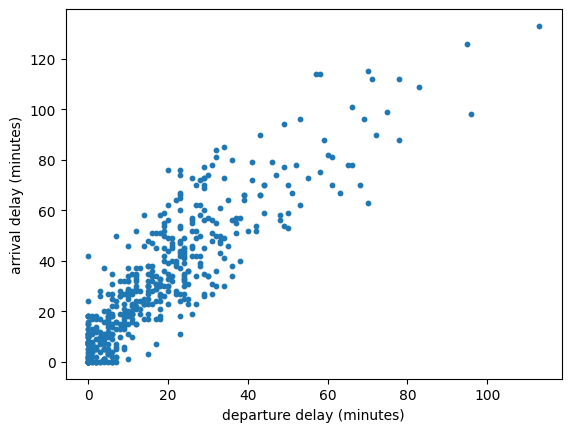

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df['departure_delay_mins'], df['arrival_delay_mins'], s=10)
plt.xlabel('departure delay (minutes)')
plt.ylabel('arrival delay (minutes)')
plt.show()

Two different questions can be asked of these flights. They belong to two different ways of doing analysis:

| | **Statistical inference** (traditional regression) | **Machine learning** |
|---|---|---|
| Question | *Is* departure delay related to arrival delay, and *how strongly*? | *How late will the next flight arrive?* |
| What we want | The relationship: the coefficient $\beta_1$ | A prediction $\hat{y}$ ("y-hat") for flights not in the data yet |
| Why we trust the answer | **Probability theory.** The standard error and p-value say whether the estimate could be just chance | **A test.** Try the model on flights it has never seen and measure how far off it is |
| Data | Use **all** 500 flights | **Split**: 75% to train the model, 25% to test it |
| Main output | Coefficient, p-value | Test R², RMSE |

**This is why the data is split in one and not the other.** Inference gets its evidence from theory, so every
flight goes into the estimate. No p-value tells you how well a model predicts. The only evidence is how it does on
data it did not learn from, so machine learning sets part of the data aside as a stand-in for future flights.

## Statistical inference: explain the relationship

$$\text{arrival delay} = \beta_0 + \beta_1 \times \text{departure delay} + \varepsilon$$

$\beta_1$ is the true slope for flights in general: on average, how many more minutes late a flight arrives for
each extra minute it leaves late. We estimate it from these 500 flights and ask whether it could really be 0.

$\varepsilon$ (epsilon, the **error term**) is the part of each flight's arrival delay that the line does not
explain, such as the weather.

`smf.ols` fits the line by **OLS (Ordinary Least Squares)**: it picks the line that makes the sum of the squared
misses as small as possible.

In [13]:
import statsmodels.formula.api as smf

results = smf.ols('arrival_delay_mins ~ departure_delay_mins', data=df).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     arrival_delay_mins   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     1733.
Date:                Fri, 09 Oct 2026   Prob (F-statistic):          2.66e-164
Time:                        14:25:07   Log-Likelihood:                -1965.3
No. Observations:                 500   AIC:                             3935.
Df Residuals:                     498   BIC:                             3943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                8.6834 

**How to read it**
- `coef` of `departure_delay_mins`: the estimate of $\beta_1$.
- `std err`: the **standard error**, how much this estimate would change with a different sample of flights.
  Smaller means more precise.
- `P>|t|`: the p-value. Near 0 means a relationship this strong is very unlikely if $\beta_1$ were really 0.
- `[0.025  0.975]`: the 95% confidence interval for $\beta_1$.
- `R-squared`: the share of the variation in arrival delays that departure delay accounts for, in these 500 flights.

Report it like this: *Departure delay was significantly related to arrival delay, b = 1.29, p < .001,
R² = 0.777, n = 500. Each extra minute of departure delay went with about 1.3 more minutes of arrival delay.*

The answer is about the **relationship**. It does not tell us how far off we would be for any one new flight.

## Machine learning: predict new flights

Now the question is about a **new** flight: if it leaves 30 minutes late, how late will it arrive?

To know whether the model predicts well, we need flights it has not seen. So we set 25% of the flights aside as the
**test set** (they play the role of future flights), fit the model on the other 75% (the **training set**), and then
compare its predictions on the test set with what actually happened.

In [14]:
from sklearn.model_selection import train_test_split

X = df[['departure_delay_mins']]   # input
y = df['arrival_delay_mins']       # what we predict

# test_size=0.25: 25% of the flights go to the test set
# random_state=0: the same random split every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [15]:
from sklearn.linear_model import LinearRegression

ml_model = LinearRegression()
ml_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


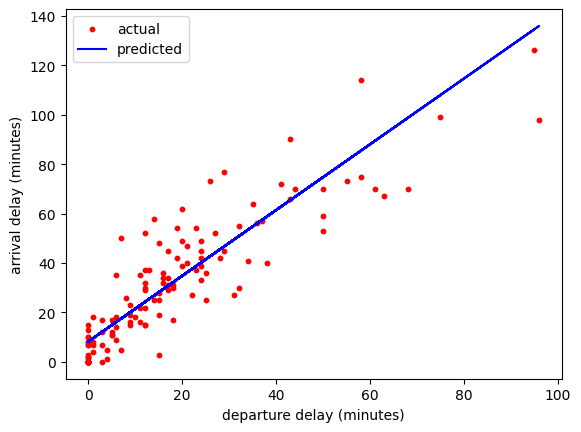

In [16]:
y_pred = ml_model.predict(X_test)

plt.scatter(X_test['departure_delay_mins'], y_test, color='red', s=10, label='actual')
plt.plot(X_test['departure_delay_mins'], y_pred, color='blue', label='predicted')
plt.xlabel('departure delay (minutes)')
plt.ylabel('arrival delay (minutes)')
plt.legend()
plt.show()

**How far off are the predictions on the test set?** For each test flight, the miss is $y_i - \hat y_i$
(actual minus predicted).

- **R²** (R-squared): the share of the variation in arrival delays that the predictions capture. 1 is perfect;
  0 is no better than always guessing the average delay $\bar y$.
- **MSE** (Mean Squared Error): square each miss, then average. Squaring keeps plus and minus misses from canceling
  out, but the unit becomes minutes².
- **RMSE** (Root Mean Squared Error): the square root of the MSE. It is back in minutes, so read it as the typical
  size of a miss.

$$R^2 = 1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}
\qquad
\text{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
\qquad
\text{RMSE}=\sqrt{\text{MSE}}$$

In [17]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print('Test R2:', round(ml_model.score(X_test, y_test), 3))
print('MSE:    ', round(mse, 1), 'minutes squared')
print('RMSE:   ', round(mse ** 0.5, 1), 'minutes')

Test R2: 0.78
MSE:     153.8 minutes squared
RMSE:    12.4 minutes


Now use the model the way an airline would: predict a flight that leaves 30 minutes late.

In [18]:
new_flight = pd.DataFrame({'departure_delay_mins': [30]})
ml_model.predict(new_flight).round(1)

array([48.1])

The answer is a **number for one flight**, and the RMSE says how far off such a number typically is.

### Your turn

A flight leaves **45 minutes** late.

1. In the cell below, fill in the two blanks (`___`) and run it to predict the flight's arrival delay.
2. Then finish this sentence, using the RMSE above:
   *This flight should arrive about ___ minutes late, give or take about ___ minutes.*

<details><summary>Show answer</summary>

```python
new_flight = pd.DataFrame({'departure_delay_mins': [45]})
ml_model.predict(new_flight).round(1)
```

*This flight should arrive about **68.1** minutes late, give or take about **12.4** minutes.*
</details>

In [ ]:
new_flight = pd.DataFrame({'departure_delay_mins': [___]})
ml_model.___(new_flight).round(1)

---
## Summary

| | Statistical inference | Machine learning |
|---|---|---|
| Question | Is there a relationship, and how big is it? | What will happen to a new case? |
| Answer | A coefficient with its p-value | A prediction with its typical error (RMSE) |
| Evidence | Probability theory, using all the data | A test on data the model never saw |
| Tool here | `statsmodels` (`smf.ols`) | `scikit-learn` (`LinearRegression`) |

**Read:** Leo Breiman (2001), [Statistical Modeling: The Two Cultures](https://doi.org/10.1214/ss/1009213726),
*Statistical Science* 16(3).

**Next:** the assignment adds the weather to the inference model. One more input, one more `+`.